In [1]:
%matplotlib widget
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy
import h5py

import os
import sys
sys.path.append(os.path.abspath("./"))

print(os.getpid())
%cd ../../

import pylib.mix as mix
import carleman as ca
from matplotlib import colors
plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r"\usepackage{amsmath} \boldmath"
})

1652
c:\Users\ivan9\Documents\work\codes\QuCF\scripts-py


In [2]:
path_save_ = "./jupyter-notebooks/Carleman/results/"
for i in range(100):
    plt.close()

colors_     = ["blue", "red", "green", "gray", "black"]
linestyles_ = ["-", "--", "--", ":"]

init. cond.:   0.00   0.40   0.00 




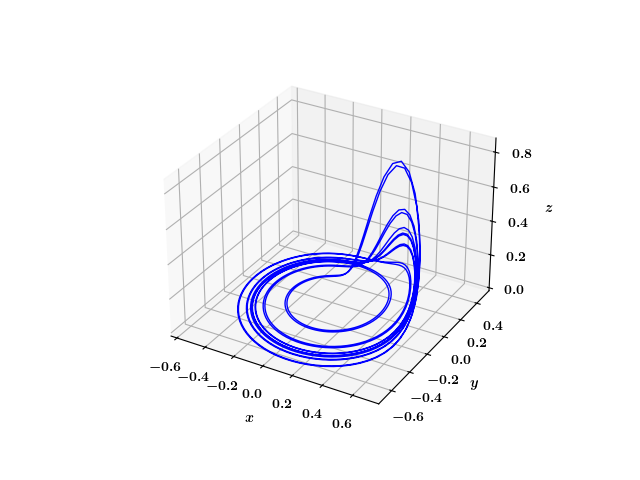

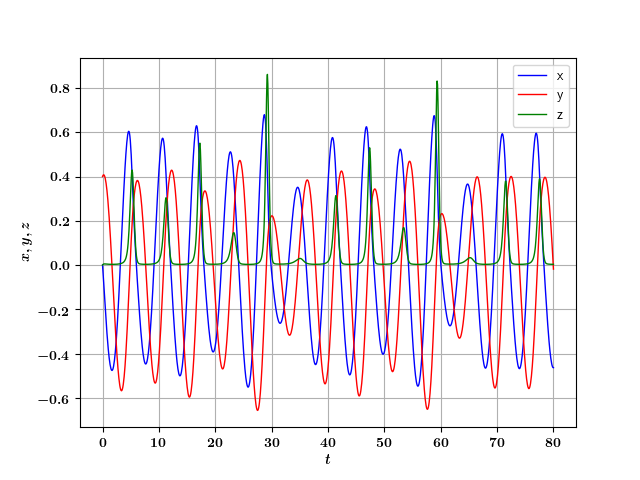

In [40]:
# ---------------------------------------------------------------
# --- Prepare the system: Roessler attractor ---
# ---------------------------------------------------------------
mix.reload_module(ca)
mix.reload_module(mix)
def choose_case(N_nl, sel_case):
    Nx = 3  # the number of degrees of freedom
    F_terms, sys_coefs, return_sys, shift_coefs = None, None, None, None

    # ----------------------------------------------------
    if sel_case == 0:
        F_terms = [None] * (N_nl + 1)
        for ii_nl in range(N_nl + 1):
            F_terms[ii_nl] = np.zeros((Nx,int(Nx**ii_nl)))

        tmax, nt = 80, 12

        # ss, rr, bb = 0.2, 5.7, 0.2
        # ss, rr, bb = 0.4, 6., 0.2
        ss, rr, bb, eta = 0.2, 6., 0.6, 2.

        xi_x, xi_y, xi_z = 0., 0., 0.
        x_init = np.array([0.0, 0.4, 0.0])

        # F = [
        #     lambda x: - x[1] - x[2],
        #     lambda x: x[0] + ss * x[1],
        #     lambda x: bb - rr * x[2] + x[0] * x[2]
        # ]

        F = [
            lambda x: - x[1] - x[2],
            lambda x: x[0] + ss * x[1],
            lambda x: bb/(eta*rr) - rr * x[2] + eta*rr * x[0] * x[2]
        ]

    # ----------------------------------------------------------
    if sel_case == 1:
        tmax, nt = 80, 10
        # tmax, nt = 14, 9

        # ss, rr, bb, eta = 0.2, 6., 0.6, 2.
        ss, rr, bb, eta = 0.2, 6., 0.6, 2.4

        xi_x, xi_y, xi_z = 0., 0., 0.
        x_init = np.array([0.0, 0.4, 0.0])

        sys_coefs = {}
        sys_coefs["ss"]   = ss
        sys_coefs["rr"]   = rr
        sys_coefs["bb"]   = bb
        sys_coefs["eta"]  = eta
        sys_coefs["xi_x"] = xi_x
        sys_coefs["xi_y"] = xi_y
        sys_coefs["xi_z"] = xi_z

        # -------------------------------------------------------------
        def return_sys(ss_coefs):
            ss   = ss_coefs["ss"]    
            rr   = ss_coefs["rr"]    
            bb   = ss_coefs["bb"] 
            eta  = ss_coefs["eta"]   
            xi_x = ss_coefs["xi_x"]  
            xi_y = ss_coefs["xi_y"]  
            xi_z = ss_coefs["xi_z"]  

            F_terms = [None] * (N_nl + 1)
            for ii_nl in range(N_nl + 1):
                F_terms[ii_nl] = np.zeros((Nx,int(Nx**ii_nl)))

            # *** Equation 0 ***
            F_terms[0][0,0] = - (xi_y + xi_z)
            F_terms[1][0,1] = -1.
            F_terms[1][0,2] = -1.

            # *** Equation 1 ***
            F_terms[0][1,0] = xi_x + ss * xi_y
            F_terms[1][1,0] = 1.
            F_terms[1][1,1] = ss

            # *** Equation 2 ***
            F_terms[0][2,0] = bb/(rr * eta) - rr*xi_z + eta * rr * xi_x*xi_z
            F_terms[1][2,0] = eta * rr * xi_z
            F_terms[1][2,2] = eta * rr * xi_x - rr
            F_terms[2][2,2] = eta * rr
            return F_terms
        
        # -------------------------------------------------------------
        def shift_coefs(ss, zeta):
            ss_new = dict(ss)
            ss_new["xi_x"] = ss_new["xi_x"] + zeta[0]
            ss_new["xi_y"] = ss_new["xi_y"] + zeta[1]
            if "xi_z" in ss_new:
                ss_new["xi_z"] = ss_new["xi_z"] + zeta[2]
            return ss_new

        # --- construct the system ---
        F_terms = return_sys(sys_coefs)
        F = [
            lambda x: F_terms[0][0,0] + F_terms[1][0,1] * x[1] + F_terms[1][0,2] * x[2],
            lambda x: F_terms[0][1,0] + F_terms[1][1,0] * x[0] + F_terms[1][1,1] * x[1],
            lambda x: F_terms[0][2,0] + F_terms[1][2,0] * x[0] + F_terms[1][2,2] * x[2] + F_terms[2][2,2] * x[0] * x[2]
        ]

    # ----------------------------------------------------
    return F, tmax, nt, Nx, x_init, F_terms, sys_coefs, return_sys, shift_coefs
# ------------------------------------------------------------------------------
sel_case_ = 1

N_nl_orig_ = 2
F_, tmax_, nt_, Nx_, x_init_ref_, F_terms_, sys_coefs_, return_sys_, shift_coefs_ = choose_case(N_nl_orig_, sel_case = sel_case_)
Nt_ = 1 << nt_
t_ = np.linspace(0, tmax_, Nt_)
dt_ = np.diff(t_)[0]

print("init. cond.: ", end = "")
mix.print_array(x_init_ref_, ff = [6, 2, "f"])

# --- Standard method (for reference) ---
sol_ref_, t_ref_ = ca.analyse_classical(x_init_ref_, t_, F_)

In [41]:
# --------------------------------------------------------------------
# --- Carleman linearization ---
# --------------------------------------------------------------------
mix.reload_module(ca)
N_nl = 6   # should be >= N_nl_orig_

# sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_orig(x_init_ref_, N_nl, N_nl_orig_, t_, return_sys_(sys_coefs_))

sol_emb_, t_emb_, case_emb_ = ca.solve_carleman_global(
    x_init_ref_, N_nl, N_nl_orig_, t_, 
    sys_coefs_, return_sys_, shift_coefs_,
    zeta_th = 0.1
)

The total number of variables in the embedding: 1092
--- Shift to another chart, t = 0.005 ---
radius: 0.4
zeta_gl:  -0.00   0.40   0.00 
xs:     -1.935e-03      4.004e-01      1.985e-04 

--- Shift to another chart, t = 0.251 ---
radius: 0.1
zeta_gl:  -0.10   0.41   0.00 
xs:     -1.006e-01      7.181e-03      4.698e-03 

--- Shift to another chart, t = 0.496 ---
radius: 0.1
zeta_gl:  -0.20   0.39   0.00 
xs:     -9.971e-02     -1.783e-02      4.145e-05 

--- Shift to another chart, t = 0.742 ---
radius: 0.1
zeta_gl:  -0.29   0.35   0.00 
xs:     -9.212e-02     -4.302e-02     -6.321e-04 

--- Shift to another chart, t = 0.988 ---
radius: 0.1
zeta_gl:  -0.37   0.28   0.00 
xs:     -7.844e-02     -6.680e-02     -4.967e-04 

--- Shift to another chart, t = 1.233 ---
radius: 0.1
zeta_gl:  -0.43   0.19   0.00 
xs:     -5.929e-02     -8.764e-02     -3.185e-04 

--- Shift to another chart, t = 1.479 ---
radius: 0.1
zeta_gl:  -0.47   0.09   0.00 
xs:     -3.557e-02     -1.041e-01     -1.798e-

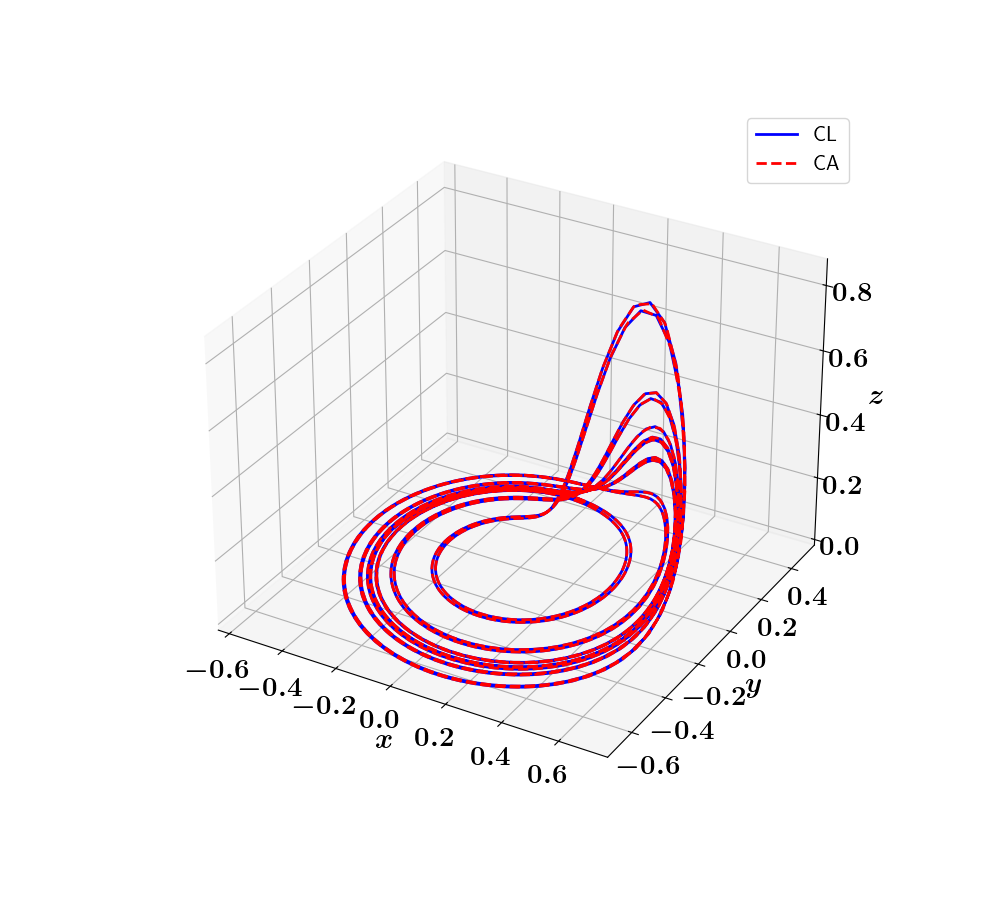

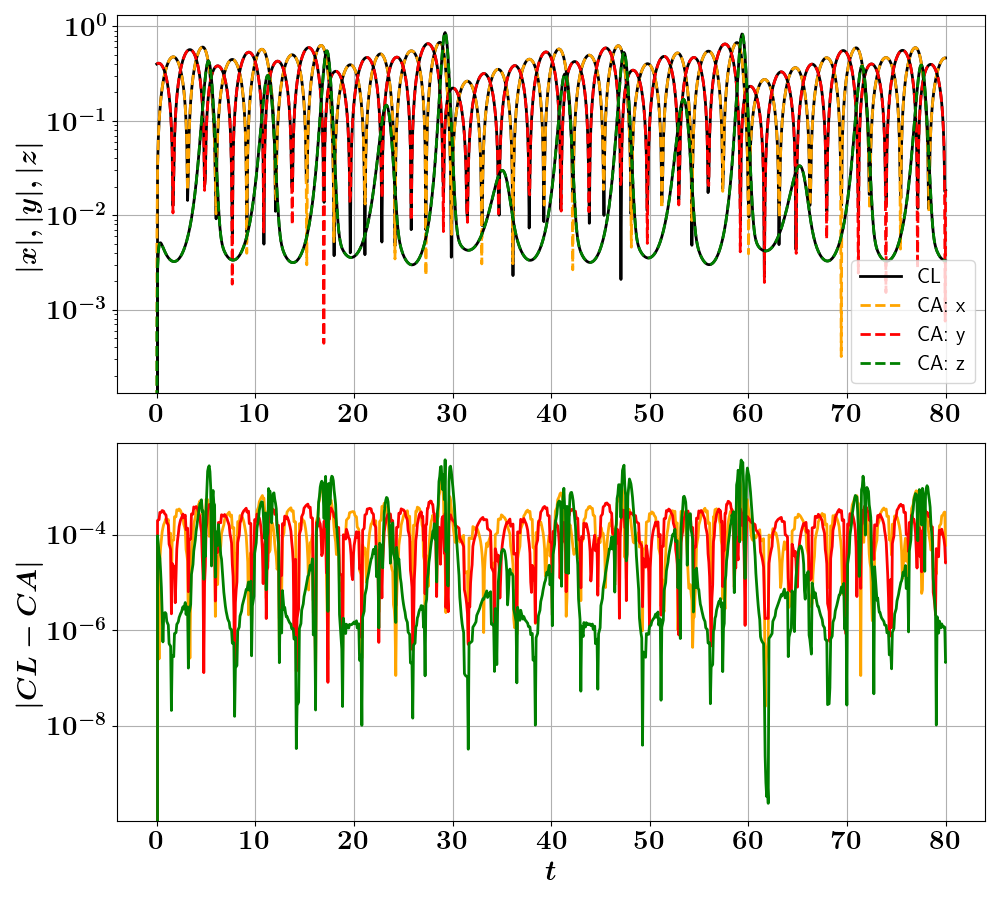

In [42]:
# --------------------------------------------------------------------
# --- Compare trajectories ---
# --------------------------------------------------------------------
mix.reload_module(ca)
ca.compare_trajectory_cl_and_carleman(
    t_ref_, sol_ref_, t_emb_, sol_emb_,
    flag_save=False, path_save=path_save_, 
    case_title = "SoA", case_emb = case_emb_
)